In [1]:
# created by: Carlos Henrique Soares da Silva
# description: Code making the model of a galaxy with a exponential sfh based in the 
# galaxy presented in https://ui.adsabs.harvard.edu/abs/2018MNRAS.480.4379C/abstract 
# with S-PLUS filters

In [2]:
# imports

import bagpipes as pipes
import numpy as np

Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: PyMultiNest import failed, fitting will use the Nautilus sampler instead.


In [29]:
# defining the model_components dict

# sfh
exp = {}
exp["age"] = 10.
exp["tau"] = 5.
exp["massformed"] = 11.
exp["metallicity"] = 0.8 

# dust
dust = {}
dust["type"] = "Calzetti"
dust["Av"] = 0.2
dust["eta"] = 3.

#nebular attenuation and emission
nebular = {}
nebular["logU"] = -3.

# setting the model
model_components = {}
model_components["redshift"] = 0.
model_components["t_bc"] = 0.01
model_components["veldisp"] = 300.
model_components["exponential"] = exp
model_components["dust"] = dust
model_components["nebular"] = nebular

# making the model
model = pipes.model_galaxy(model_components)

In [30]:
# defining observables

# fotometry
splus_filt_list = ["/home/carlos/Desktop/Mestrado/python/bagpipes/filtros/uJAVA.dat",
                   "/home/carlos/Desktop/Mestrado/python/bagpipes/filtros/F0378.dat",
                   "/home/carlos/Desktop/Mestrado/python/bagpipes/filtros/F0395.dat",
                   "/home/carlos/Desktop/Mestrado/python/bagpipes/filtros/F0410.dat",
                   "/home/carlos/Desktop/Mestrado/python/bagpipes/filtros/F0430.dat",
                   "/home/carlos/Desktop/Mestrado/python/bagpipes/filtros/gSDSS.dat",
                   "/home/carlos/Desktop/Mestrado/python/bagpipes/filtros/F0515.dat",
                   "/home/carlos/Desktop/Mestrado/python/bagpipes/filtros/rSDSS.dat",
                   "/home/carlos/Desktop/Mestrado/python/bagpipes/filtros/F0660.dat",
                   "/home/carlos/Desktop/Mestrado/python/bagpipes/filtros/iSDSS.dat",
                   "/home/carlos/Desktop/Mestrado/python/bagpipes/filtros/F0861.dat",
                   "/home/carlos/Desktop/Mestrado/python/bagpipes/filtros/zSDSS.dat"]

# spectroscopy
obs_wavs = np.arange(2000., 7000., 5.)

In [31]:
%%time

# making the model
model = pipes.model_galaxy(model_components, filt_list=splus_filt_list, spec_wavs=obs_wavs)

CPU times: user 568 ms, sys: 20 ms, total: 588 ms
Wall time: 588 ms


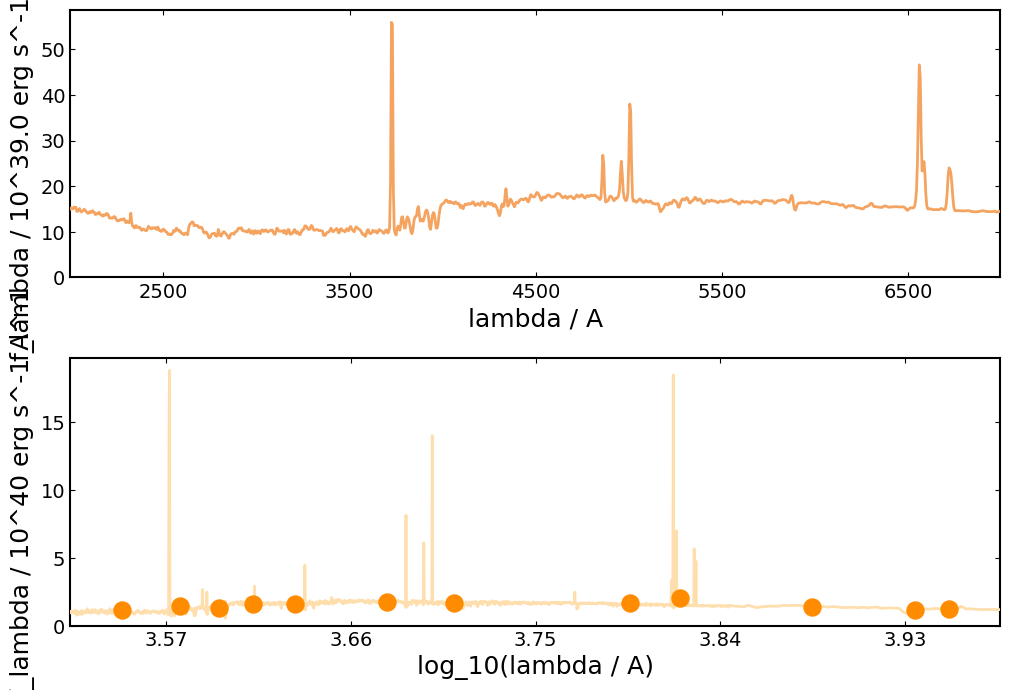

(<Figure size 1200x800 with 2 Axes>,
 [<Axes: xlabel='lambda / A', ylabel='f_lambda / 10^39.0 erg s^-1 A^-1'>,
  <Axes: xlabel='log_10(lambda / A)', ylabel='f_lambda / 10^40 erg s^-1 A^-1'>])

In [32]:
# plotting the model
model.plot()

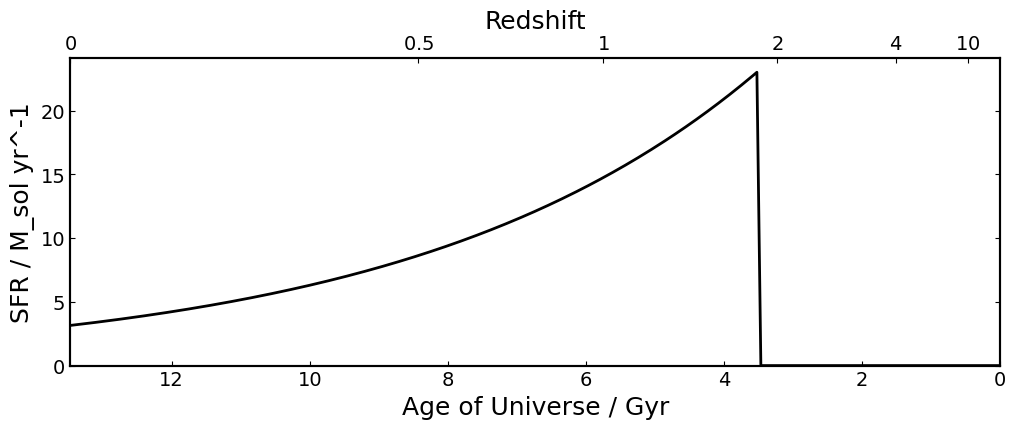

In [33]:
# plotting the sfh
fig = model.sfh.plot()